In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
# Load MCS track file (HPC)
mcs_file_obs = "//pscratch/sd/f/feng045/waccem/mcs_global/stats/mcs_tracks_final_extc_20200101.0000_20210101.0000.nc"
ds_mcs_obs = xr.open_dataset(mcs_file_obs)

mcs_file_icon = "/global/cfs/cdirs/m4581/gsharing/hackathon/tracking/mcs/icon_d3hp003/stats/mcs_tracks_final_20200102.0000_20201231.2330.nc"
ds_mcs_icon = xr.open_dataset(mcs_file_icon)

mcs_file_scream = "/global/cfs/cdirs/m4581/gsharing/hackathon/tracking/mcs/scream/stats/mcs_tracks_final_20190801.0000_20200901.0000.nc"
ds_mcs_scream = xr.open_dataset(mcs_file_scream)

mcs_file_um = "/global/cfs/cdirs/m4581/gsharing/hackathon/tracking/mcs/um_glm_n2560_RAL3p3/stats/mcs_tracks_final_20200201.0000_20210301.0000.nc"
ds_mcs_um = xr.open_dataset(mcs_file_um)

mcs_file_ifs = "/pscratch/sd/p/paccini/IFS_mcs_hackathon/ifs_tco3999_rcbmf/stats/mcs_tracks_final_20200101.0000_20210228.2330.nc"
ds_mcs_ifs = xr.open_dataset(mcs_file_ifs)

mcs_file_nicam = "/pscratch/sd/w/wcmca1/hackathon/mcs/nicam_gl11/stats/mcs_tracks_final_20200301.0000_20210301.0000.nc"
ds_mcs_nicam = xr.open_dataset(mcs_file_nicam)

In [3]:
mcs_file_obs_v7 = "/global/cfs/cdirs/wcm_shr/hk25/mcs/IMERGv7/stats/mcs_tracks_final_20190801.0000_20200901.0000.nc"
ds_mcs_obs_v7 = xr.open_dataset(mcs_file_obs_v7)

In [ ]:
mcs_stats = 'df_filtered_mcs_track_ids/'
df_trop_obs2= pd.read_pickle(mcs_stats+'with_circular_lffiltered_obs_min2_r2.pkl')
df_trop_obs2v7= pd.read_pickle(mcs_stats+'with_circular_lffiltered_obs_v7_min2_r2.pkl')
df_trop_icon2= pd.read_pickle(mcs_stats+'with_circular_lffiltered_icon_min2_r2.pkl')
df_trop_scream2= pd.read_pickle(mcs_stats+'with_circular_lffiltered_scream_min2_r2.pkl')
df_trop_um2= pd.read_pickle(mcs_stats+'with_circular_lffiltered_um_min2_r2.pkl') 
df_trop_ifs2= pd.read_pickle(mcs_stats+'with_circular_lffiltered_ifs_min2.pkl')
df_trop_nicam2= pd.read_pickle(mcs_stats+'with_circular_lffiltered_nicam_min2_r2.pkl')

In [4]:
mcs_stats = 'df_filtered_mcs_track_ids/'
TRACK_MODELS = ['um', 'icon', 'scream', 'ifs', 'nicam', 'obs', 'obs_v7'] 

In [6]:
import glob
import os

In [17]:
def remove_long_and_land(df_model, feature='duration_hours', p_high=0.9, 
                         lf_thresh=0.1,lf_var='total_land_fraction_track'):
    if df_model is None:
        return None
    q_high = df_model[feature].quantile(p_high)
    df_filtered = df_model[(df_model[feature] <= q_high)].copy()
    final_df = df_filtered[df_filtered[lf_var] <= lf_thresh].copy()
    return final_df

In [18]:
# --- Load Track Data ---
raw_track_data = {}
crit = 'min2'
for model in TRACK_MODELS:
    raw_track_data[model] = {}
    try:
        crit_suffix = 'min2'
        path = os.path.join(mcs_stats, f'with_circular_lffiltered_{model}_{crit_suffix}_r2.pkl')
        raw_track_data[model] = pd.read_pickle(path)
    except Exception as e:
        print(f"Warning: Could not load track data for {model} - {crit}. Error: {e}")
        raw_track_data[model] = None

In [23]:
len(remove_long_and_land(raw_track_data['icon']).track_id.values)

900

In [ ]:
model_colors = {
        'ERA5_IMERGv7': 'k',
        'ERA5_IMERGv6': 'gray',
        'ICON': '#ff7f0e',
        'SCREAM': '#2ca02c',
        'UM': 'salmon',
        'IFS':"steelblue", "NICAM":"mediumpurple"
    }

In [46]:
import matplotlib.pyplot as plt

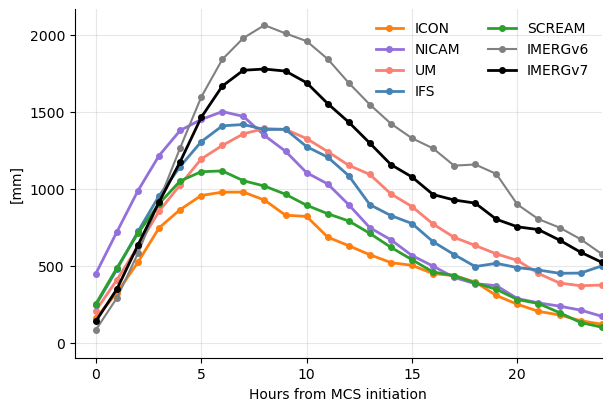

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4), constrained_layout=True)

ds_mcs_icon.sel(
    tracks=remove_long_and_land(raw_track_data['icon']).track_id.values).total_rain.to_dataframe().reset_index().groupby(
    'times').median()['total_rain'].plot(ax=ax,color='#ff7f0e',lw=2,label='ICON',
                                         marker='o',  markersize=4)
ds_mcs_nicam.sel(
    tracks=remove_long_and_land(raw_track_data['nicam']).track_id.values).total_rain.to_dataframe().reset_index().groupby(
    'times').median()['total_rain'].plot(ax=ax,color='mediumpurple',lw=2,label='NICAM',
                                         marker='o',  markersize=4)
ds_mcs_um.sel(
    tracks=remove_long_and_land(raw_track_data['um']).track_id.values).total_rain.to_dataframe().reset_index().groupby(
    'times').median()['total_rain'].plot(ax=ax,color='salmon',lw=2,label='UM',
                                         marker='o',  markersize=4)
ds_mcs_ifs.sel(
    tracks=remove_long_and_land(raw_track_data['ifs']).track_id.values).total_rain.to_dataframe().reset_index().groupby(
    'times').median()['total_rain'].plot(ax=ax,color='steelblue',lw=2,label='IFS',
                                         marker='o',  markersize=4)
ds_mcs_scream.sel(
    tracks=remove_long_and_land(raw_track_data['scream']).track_id.values).total_rain.to_dataframe().reset_index().groupby(
    'times').median()['total_rain'].plot(ax=ax,color='#2ca02c',lw=2,label='SCREAM',
                                         marker='o',  markersize=4)
ds_mcs_obs.sel(
    tracks=remove_long_and_land(raw_track_data['obs']).track_id.values).total_rain.to_dataframe().reset_index().groupby(
    'times').median()['total_rain'].plot(ax=ax,color='gray',label='IMERGv6',
                                         marker='o',  markersize=4)
ds_mcs_obs_v7.sel(
    tracks=remove_long_and_land(raw_track_data['obs_v7']).track_id.values).total_rain.to_dataframe().reset_index().groupby(
    'times').median()['total_rain'].plot(ax=ax,color='k',lw=2,label='IMERGv7',
                                         marker='o',  markersize=4,)

ax.set_xlim(-1,24)
ax.set_ylabel('[mm]'); ax.set_xlabel('Hours from MCS initiation')
ax.legend(fontsize=10,frameon=False,ncols=2)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('plots/evolution_totalrain_min2_longremoved.png', dpi=300, bbox_inches='tight')

In [26]:
ds_mcs_scream.sel(tracks=56407)['meanlat'][0:23].values

array([5.167857 , 5.141667 , 5.1272154, 5.048333 , 5.0262713, 5.087333 ,
       5.171612 , 5.238719 , 5.1225834, 5.0165143, 5.0627527, 5.0214767,
       4.7219353, 4.870676 , 4.9233656, 4.5588784, 4.5689573, 4.5885963,
       4.55     , 4.490625 ,       nan,       nan,       nan],
      dtype=float32)

In [27]:
ds_mcs_scream.sel(tracks=56407)['meanlon'][0:23].values

array([160.92857, 160.8375 , 160.7614 , 160.7375 , 160.66243, 160.51755,
       160.30861, 161.00237, 160.96948, 162.15779, 161.38028, 162.11017,
       163.50998, 163.76828, 163.70158, 164.3014 , 164.19266, 163.85   ,
       163.50066, 163.16016,       nan,       nan,       nan],
      dtype=float32)

In [28]:
ds_mcs_scream.sel(tracks=56407)['pf_landfrac'][0:23].values

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00680272, 0.01219512, 0.02512563,
       0.        , 0.        , 0.        , 0.        , 0.02185792,
       0.        , 0.        , 0.        , 0.        , 0.        ,
              nan,        nan,        nan], dtype=float32)

In [29]:
ds_mcs_scream.sel(tracks=56407).to_dataframe().reset_index(
    
)[['tracks','base_time','meanlat','meanlon','pf_landfrac']]

,tracks,base_time,meanlat,meanlon,pf_landfrac
0,56407,2020-08-31 05:00:00,5.167857,160.928574,0.0
1,56407,2020-08-31 05:00:00,5.167857,160.928574,0.0
2,56407,2020-08-31 05:00:00,5.167857,160.928574,0.0
3,56407,2020-08-31 05:00:00,5.167857,160.928574,0.0
4,56407,2020-08-31 05:00:00,5.167857,160.928574,0.0
...,...,...,...,...,...
97495,56407,NaT,NaN,NaN,NaN
97496,56407,NaT,NaN,NaN,NaN
97497,56407,NaT,NaN,NaN,NaN
97498,56407,NaT,NaN,NaN,NaN


In [9]:
t1 = pd.read_parquet(ldir+'SCREAM/mcs_land_fractions_scream_ne120_zoom8_summary.parquet')

<xarray.DataArray 'tracks' (tracks: 56487)> Size: 452kB
array([    0,     1,     2, ..., 56484, 56485, 56486], shape=(56487,))
Coordinates:
  * tracks   (tracks) int64 452kB 0 1 2 3 4 5 ... 56482 56483 56484 56485 56486

In [8]:
lf_scream[lf_scream.radius==2]

,track_id,radius,mean_land_fraction_track,total_land_fraction_track,num_time_points,start_lat,start_lon
0,3,2.0,0.000000,0.000000,2,26.852104,176.185120
3,4,2.0,0.000000,0.000000,69,17.869509,155.663086
6,5,2.0,0.000000,0.000000,76,11.355928,-127.199150
9,11,2.0,0.308906,5.560314,18,7.405107,10.688828
12,12,2.0,0.063855,0.957828,15,-8.511639,159.764740
...,...,...,...,...,...,...,...
129462,56377,2.0,1.000000,1.000000,1,8.025017,26.442406
129465,56378,2.0,1.000000,1.000000,1,6.083003,-67.920631
129468,56380,2.0,0.791443,0.791443,1,25.090921,-106.757637
129471,56381,2.0,0.000000,0.000000,1,11.691772,-115.828484


In [7]:
t1

,track_id,radius,mean_land_fraction_track,total_land_fraction_track,num_time_points,start_lat,start_lon
0,3,2.0,0.000000e+00,0.000000,2,26.852104,176.185120
1,3,3.5,0.000000e+00,0.000000,2,26.852104,176.185120
2,3,5.0,0.000000e+00,0.000000,2,26.852104,176.185120
3,4,2.0,0.000000e+00,0.000000,69,17.869509,155.663086
4,4,3.5,3.422340e-07,0.000024,69,17.869509,155.663086
...,...,...,...,...,...,...,...
129472,56381,3.5,0.000000e+00,0.000000,1,11.691772,-115.828484
129473,56381,5.0,0.000000e+00,0.000000,1,11.691772,-115.828484
129474,56382,2.0,1.000000e+00,1.000000,1,10.393903,4.686585
129475,56382,3.5,1.000000e+00,1.000000,1,10.393903,4.686585


In [8]:
# test = xr.open_dataset('/pscratch/sd/w/wcmca1/hackathon/mcs/nicam_gl11/mcstracking/nicam_hrly_mcsmask_hp8_v1.zarr')

In [18]:
# test_icon = xr.open_dataset('/pscratch/sd/w/wcmca1/hackathon/mcs/icon_d3hp003/mcstracking/icon_hrly_mcsmask_hp8_v1.zarr')

In [39]:
!ls -ltr /pscratch/sd/w/wcmca1/hackathon/mcs/nicam_gl11/mcstracking/

total 704
drwxrws--- 2 feng045 m1867 716800 Oct  5 08:32 20200301.0000_20210301.0000
drwxrws--- 8 feng045 m1867   4096 Oct  6 15:44 nicam_hrly_mcsmask_hp8_v1.zarr


In [ ]:
# Load MCS track file (local)
# mcs_file_obs = "/Users/pacc275/local_documents/hackathon/mcs_tracks_final_extc_20200101.0000_20210101.0000.nc"
# ds_mcs_obs = xr.open_dataset(mcs_file_obs)

# mcs_file_icon = "/Users/pacc275/local_documents/hackathon/mcs_final_icon_20200102.0000_20201231.2330.nc"
# ds_mcs_icon = xr.open_dataset(mcs_file_icon)

# mcs_file_scream = "/Users/pacc275/local_documents/hackathon/mcs_tracks_final_20190801.0000_20200901.0000.nc"
# ds_mcs_scream = xr.open_dataset(mcs_file_scream)

# mcs_file_um = "/Users/pacc275/local_documents/hackathon/mcs_tracks_final_um_20200201.0000_20210301.0000.nc"
# ds_mcs_um = xr.open_dataset(mcs_file_um)

In [4]:
def MCS_filter(ds_mcs,ilat = -30, elat = 30,filter_split=True,min_ini_nonmcs=3,nomerging=False,nopeak=False,):
    #i) MCS do not start with a split 
    if filter_split:
        mask = np.isnan(ds_mcs.start_split_cloudnumber)
        ds_nosplit = ds_mcs.sel(tracks=mask)
        del(ds_mcs)
        ds_mcs = ds_nosplit.copy()
    # Also apply spatial filtering 
    initial_lats = ds_mcs.meanlat.isel(times=0).values
    initial_lons = ds_mcs.meanlon.isel(times=0).values
    
    # ii) Tropical filter (-30 to 30 latitude) & landfraction
    mask_tropical = (initial_lats >= ilat) & (initial_lats <= elat)
    mask_lf = ds_mcs.pf_landfrac.sum('times') < 0.1 ## land fraction less than 10% during whole lifetime

    # iv) No merging 
    mask_start_status = (ds_mcs.start_status == 1) | (ds_mcs.start_status == 2)
    mask_end_status = (ds_mcs.end_status == 0) | (ds_mcs.end_status == 3)

    # v)  MCSs with first three time steps are non MCSs
    mask_initial_non_mcs = ds_mcs.mcs_status.isel(times=slice(0, min_ini_nonmcs)).sum(dim='times') == 0
    mask_initial_non_mcs = mask_initial_non_mcs.drop_vars('times', errors='ignore')

    # vi) stable MCSs & total rain peak within MCS status 
    # Sum the mcs_status (0s and 1s) over time. This sum must equal the total mcs_duration.
    mcs_hours_sum = ds_mcs.mcs_status.sum(dim='times')
    mask_continuous_mcs = (mcs_hours_sum == ds_mcs.mcs_duration)
    mask_continuous_mcs = mask_continuous_mcs.drop_vars('times', errors='ignore')


    # Total rainfall must peak during an MCS status (mcs_status == 1)
    peak_rain_time_idx = ds_mcs.total_rain.argmax(dim='times')
    status_at_peak_rain = ds_mcs.mcs_status.isel(times=peak_rain_time_idx)
    # The mask is true where that status is 1.
    mask_peak_rain = (status_at_peak_rain == 1)
    mask_peak_rain = mask_peak_rain.drop_vars('times', errors='ignore')

    # final extracted MCSs
    if nomerging:
        final_mcs = ((mask_tropical) & (mask_lf) &  \
                                  (mask_peak_rain) & (mask_initial_non_mcs) & (mask_continuous_mcs))
    elif nopeak:
        final_mcs = ((mask_tropical) & (mask_lf) & (mask_start_status) & (mask_end_status) & \
                                 (mask_initial_non_mcs) )
    else:
        final_mcs = ((mask_tropical) & (mask_lf) & (mask_start_status) & (mask_end_status) & \
                                  (mask_peak_rain) & (mask_initial_non_mcs) & (mask_continuous_mcs))
        
    ## Apply final combined mask 
    final_ds = ds_mcs.where(final_mcs, drop=True)

    # Create a summary DataFrame
    tracks_of_interest = pd.DataFrame({
        'track_id':  final_ds.tracks.values,
        'duration_hours': final_ds.track_duration.values,
        'time_to_max_area': final_ds.area.argmax(dim="times").values.astype(int),
        'time_to_max_total_rain': final_ds.total_rain.argmax(dim="times").values.astype(int),
        'initial_lat': final_ds.meanlat.isel(times=0).values,
        'initial_lon': final_ds.meanlon.isel(times=0).values,
        'lifetime_maxmax_pf_area': final_ds.pf_area.max('times').max('nmaxpf').values,
        # 'lifetime_maxmean_pf_area': tropical_lifetime_maxmean_pf_area,
        # 'lifetime_maxmedian_pf_area': tropical_lifetime_maxmedian_pf_area,
        'mean_area': final_ds.area.mean('times').values,
        'median_area': final_ds.area.median('times').values,
        'total_area': final_ds.area.sum('times').values,
        'max_total_rain': final_ds.total_rain.max('times').values,
        'mean_total_rain': final_ds.total_rain.mean('times').values,
        'median_total_rain': final_ds.total_rain.median('times').values,
        'total_total_rain': final_ds.total_rain.sum('times').values,
        'mean_pf_rain': final_ds.pf_rainrate.mean(['times','nmaxpf']).values,
        'median_pf_rain': final_ds.pf_rainrate.median(['times','nmaxpf']).values,
        'total_pf_rain': final_ds.pf_rainrate.sum(['times','nmaxpf']).values,
        'mean_landfrac': final_ds.pf_landfrac.mean('times').values,
        'total_landfrac': final_ds.pf_landfrac.sum('times').values,
        'start_time': final_ds.start_basetime.values,
        'mean_eccentricity': final_ds.pf_eccentricity.mean(['times','nmaxpf']).values,
        'mean_aspectratio': final_ds.pf_aspectratio.mean(['times','nmaxpf']).values,
        'mean_majoraxis': final_ds.pf_majoraxis.mean(['times','nmaxpf']).values,
        'mean_minoraxis': final_ds.pf_minoraxis.mean(['times','nmaxpf']).values,
        'mean_orientation': final_ds.pf_orientation.mean(['times','nmaxpf']).values,
        'median_eccentricity': final_ds.pf_eccentricity.median(['times','nmaxpf']).values,
        'median_aspectratio': final_ds.pf_aspectratio.median(['times','nmaxpf']).values,
        'median_majoraxis': final_ds.pf_majoraxis.median(['times','nmaxpf']).values,
        'median_minoraxis': final_ds.pf_minoraxis.median(['times','nmaxpf']).values,
        'median_orientation': final_ds.pf_orientation.median(['times','nmaxpf']).values
        
    })

    return(tracks_of_interest)

In [5]:
def analyze_filter_impact(ds_mcs, ilat=-30, elat=30, min_ini_nonmcs=3):
    """
    Applies a series of vectorized filters, analyzes the impact of each filter,
    and returns the final filtered data along with the impact analysis.
    """
    # --- 1. Create a boolean mask for each individual condition ---

    # Baseline conditions
    mask_nosplit = ds_mcs.start_split_cloudnumber.isnull()
    initial_lats = ds_mcs.meanlat.isel(times=0)
    mask_tropical = (initial_lats >= ilat) & (initial_lats <= elat)
    mask_tropical = mask_tropical.drop_vars('times', errors='ignore') # Avoid coordinate conflicts
    mask_lf = ds_mcs.pf_landfrac.sum('times') < 0.1

    # Additional filtering conditions
    # No merging
    mask_start_status = (ds_mcs.start_status == 1) | (ds_mcs.start_status == 2)
    mask_end_status = (ds_mcs.end_status == 0) | (ds_mcs.end_status == 3)
    mask_merging = mask_start_status & mask_end_status

    # Initial Non-MCS Status
    mask_initial_non_mcs = (ds_mcs.mcs_status.isel(times=slice(0, min_ini_nonmcs)).sum(dim='times') == 0)
    mask_initial_non_mcs = mask_initial_non_mcs.drop_vars('times', errors='ignore')

    # Stable & Rain Peak in MCS 
    mcs_hours_sum = ds_mcs.mcs_status.sum(dim='times')
    mask_continuous_mcs = (mcs_hours_sum == ds_mcs.mcs_duration)
    mask_continuous_mcs = mask_continuous_mcs.drop_vars('times', errors='ignore')

    peak_rain_time_idx = ds_mcs.total_rain.argmax(dim='times')
    status_at_peak_rain = ds_mcs.mcs_status.isel(times=peak_rain_time_idx)
    mask_peak_rain = (status_at_peak_rain == 1)
    mask_peak_rain = mask_peak_rain.drop_vars('times', errors='ignore')

    mask_stability_and_peak = mask_continuous_mcs & mask_peak_rain

    # --- 2. Sequentially apply filters to analyze their impact ---
    impact_stats = []
    n_initial = ds_mcs.tracks.size

    impact_stats.append({'Filter Stage': 'Initial Total', 'Tracks Remaining': n_initial, 'Tracks Dropped': 0})

    filters_to_apply = {
        'Baseline (No Split & Tropics & LF <0.1)': mask_nosplit & mask_tropical & mask_lf,
        '+ No Merging': mask_merging,
        '+ Initial Non-MCS Status': mask_initial_non_mcs,
        '+ Stable & Rain Peak in MCS': mask_stability_and_peak
    }

    filters_to_apply_unique = {
        'Baseline (No Split & Tropics & LF <0.1)': mask_nosplit & mask_tropical & mask_lf,
        'Baseline + No Merging': mask_nosplit & mask_tropical & mask_lf & mask_merging,
        'Baseline + Initial Non-MCS Status':  mask_nosplit & mask_tropical & mask_lf & mask_initial_non_mcs,
        'Baseline + Rain Peak in MCS':  mask_nosplit & mask_tropical & mask_lf & mask_stability_and_peak,
        'Baseline + No Merging & Initial Non-MCS Status':mask_nosplit & mask_tropical & mask_lf & mask_merging & mask_initial_non_mcs,
        'Baseline + No Merging & Rain Peak in MCS':mask_nosplit & mask_tropical & mask_lf & mask_merging & mask_stability_and_peak,
        'Baseline + Initial Non-MCS Status & Rain Peak in MCS':mask_nosplit & mask_tropical & mask_lf & mask_initial_non_mcs & mask_stability_and_peak
    }

    cumulative_mask = xr.full_like(ds_mcs.tracks, fill_value=True, dtype=bool)
    previous_count = n_initial

    for name, mask in filters_to_apply.items():
        cumulative_mask &= mask
        current_count = int(cumulative_mask.sum().item())
        dropped = previous_count - current_count
        impact_stats.append({'Filter Stage': name, 'Tracks Remaining': current_count, 'Tracks Dropped': dropped})
        previous_count = current_count

    filter_impact_df = pd.DataFrame(impact_stats).set_index('Filter Stage')

    unique_impact_stats = []
    n_initial = ds_mcs.tracks.size

    unique_impact_stats.append({'Filter Stage': 'Initial Total', 'Unique Tracks': n_initial, })

    for name, mask in filters_to_apply_unique.items():
        current_count = len(mask[mask==True])
        unique_impact_stats.append({'Filter Stage': name, 'Unique Tracks': current_count})

    filter_unique_impact_df = pd.DataFrame(unique_impact_stats).set_index('Filter Stage')

    
    return filter_impact_df,filter_unique_impact_df 

In [6]:
c_impact_obsv7, i_impact_obsv7 = analyze_filter_impact(ds_mcs_obs_v7)
print("--- Filter Impact Analysis ---")
print(c_impact_obsv7)

print("\n--- Final Filtered Tracks ---")
print(i_impact_obsv7)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       40640               0
Baseline (No Split & Tropics & LF <0.1)              7682           32958
+ No Merging                                         4976            2706
+ Initial Non-MCS Status                             4365             611
+ Stable & Rain Peak in MCS                          3310            1055

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               40640
Baseline (No Split & Tropics & LF <0.1)                      7682
Baseline + No Merging                                        4976
Baseline + Initial Non-MCS Status                            6486
Baseline + Rain Peak in 

In [18]:
c_impact_obs, i_impact_obs = analyze_filter_impact(ds_mcs_obs)
print("--- Filter Impact Analysis ---")
print(c_impact_obs)

print("\n--- Final Filtered Tracks ---")
print(i_impact_obs)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       32138               0
Baseline (No Split & Tropics & LF <0.1)              6435           25703
+ No Merging                                         4200            2235
+ Initial Non-MCS Status                             3693             507
+ Stable & Rain Peak in MCS                          2825             868

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               32138
Baseline (No Split & Tropics & LF <0.1)                      6435
Baseline + No Merging                                        4200
Baseline + Initial Non-MCS Status                            5449
Baseline + Rain Peak in 

In [19]:
c_impact_obs1, i_impact_obs1 = analyze_filter_impact(ds_mcs_obs,min_ini_nonmcs=1)
print("--- Filter Impact Analysis ---")
print(c_impact_obs1)

print("\n--- Final Filtered Tracks ---")
print(i_impact_obs1)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       32138               0
Baseline (No Split & Tropics & LF <0.1)              6435           25703
+ No Merging                                         4200            2235
+ Initial Non-MCS Status                             4134              66
+ Stable & Rain Peak in MCS                          3201             933

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               32138
Baseline (No Split & Tropics & LF <0.1)                      6435
Baseline + No Merging                                        4200
Baseline + Initial Non-MCS Status                            6227
Baseline + Rain Peak in 

In [20]:
c_impact_icon, i_impact_icon = analyze_filter_impact(ds_mcs_icon)
print("--- Filter Impact Analysis ---")
print(c_impact_icon)

print("\n--- Final Filtered Tracks ---")
print(i_impact_icon)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       43577               0
Baseline (No Split & Tropics & LF <0.1)              4681           38896
+ No Merging                                         1991            2690
+ Initial Non-MCS Status                             1231             760
+ Stable & Rain Peak in MCS                           802             429

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               43577
Baseline (No Split & Tropics & LF <0.1)                      4681
Baseline + No Merging                                        1991
Baseline + Initial Non-MCS Status                            2564
Baseline + Rain Peak in 

In [21]:
c_impact_scream, i_impact_scream = analyze_filter_impact(ds_mcs_scream)
print("--- Filter Impact Analysis ---")
print(c_impact_scream)

print("\n--- Final Filtered Tracks ---")
print(i_impact_scream)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       56487               0
Baseline (No Split & Tropics & LF <0.1)              8128           48359
+ No Merging                                         4664            3464
+ Initial Non-MCS Status                             3336            1328
+ Stable & Rain Peak in MCS                          1936            1400

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               56487
Baseline (No Split & Tropics & LF <0.1)                      8128
Baseline + No Merging                                        4664
Baseline + Initial Non-MCS Status                            5518
Baseline + Rain Peak in 

In [22]:
c_impact_scream1, i_impact_scream1 = analyze_filter_impact(ds_mcs_scream,min_ini_nonmcs=1)
print("--- Filter Impact Analysis ---")
print(c_impact_scream1)

print("\n--- Final Filtered Tracks ---")
print(i_impact_scream1)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       56487               0
Baseline (No Split & Tropics & LF <0.1)              8128           48359
+ No Merging                                         4664            3464
+ Initial Non-MCS Status                             4491             173
+ Stable & Rain Peak in MCS                          2748            1743

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               56487
Baseline (No Split & Tropics & LF <0.1)                      8128
Baseline + No Merging                                        4664
Baseline + Initial Non-MCS Status                            7625
Baseline + Rain Peak in 

In [23]:
c_impact_um, i_impact_um = analyze_filter_impact(ds_mcs_um)
print("--- Filter Impact Analysis ---")
print(c_impact_um)

print("\n--- Final Filtered Tracks ---")
print(i_impact_um)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       39340               0
Baseline (No Split & Tropics & LF <0.1)              8802           30538
+ No Merging                                         4992            3810
+ Initial Non-MCS Status                             4334             658
+ Stable & Rain Peak in MCS                          2610            1724

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               39340
Baseline (No Split & Tropics & LF <0.1)                      8802
Baseline + No Merging                                        4992
Baseline + Initial Non-MCS Status                            7355
Baseline + Rain Peak in 

In [24]:
c_impact_ifs, i_impact_ifs = analyze_filter_impact(ds_mcs_ifs)
print("--- Filter Impact Analysis ---")
print(c_impact_ifs)

print("\n--- Final Filtered Tracks ---")
print(i_impact_ifs)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       32327               0
Baseline (No Split & Tropics & LF <0.1)              3132           29195
+ No Merging                                         1473            1659
+ Initial Non-MCS Status                             1203             270
+ Stable & Rain Peak in MCS                           847             356

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               32327
Baseline (No Split & Tropics & LF <0.1)                      3132
Baseline + No Merging                                        1473
Baseline + Initial Non-MCS Status                            2344
Baseline + Rain Peak in 

In [5]:
c_impact_nicam, i_impact_nicam = analyze_filter_impact(ds_mcs_nicam)
print("--- Filter Impact Analysis ---")
print(c_impact_nicam)

print("\n--- Final Filtered Tracks ---")
print(i_impact_nicam)

--- Filter Impact Analysis ---
                                         Tracks Remaining  Tracks Dropped
Filter Stage                                                             
Initial Total                                       44295               0
Baseline (No Split & Tropics & LF <0.1)              9035           35260
+ No Merging                                         5252            3783
+ Initial Non-MCS Status                             4162            1090
+ Stable & Rain Peak in MCS                          2313            1849

--- Final Filtered Tracks ---
                                                    Unique Tracks
Filter Stage                                                     
Initial Total                                               44295
Baseline (No Split & Tropics & LF <0.1)                      9035
Baseline + No Merging                                        5252
Baseline + Initial Non-MCS Status                            6990
Baseline + Rain Peak in 

In [5]:
df_trop_obs = MCS_filter(ds_mcs_obs)
df_trop_icon = MCS_filter(ds_mcs_icon)
df_trop_scream = MCS_filter(ds_mcs_scream)
df_trop_um = MCS_filter(ds_mcs_um)
df_trop_ifs = MCS_filter(ds_mcs_ifs)
df_trop_nicam = MCS_filter(ds_mcs_nicam)

In [7]:
df_trop_obsv7 = MCS_filter(ds_mcs_obs_v7)
df_trop_obsv7_min2 = MCS_filter(ds_mcs_obs_v7,min_ini_nonmcs=2)

In [15]:
!pwd

/Users/pacc275/local_documents/local_repositories/gsrm_mcs_environments/analysis


In [34]:
df_trop_obs2 = MCS_filter(ds_mcs_obs,min_ini_nonmcs=2)
df_trop_icon2 = MCS_filter(ds_mcs_icon,min_ini_nonmcs=2)
df_trop_scream2 = MCS_filter(ds_mcs_scream,min_ini_nonmcs=2)
df_trop_um2 = MCS_filter(ds_mcs_um,min_ini_nonmcs=2)
df_trop_ifs2 = MCS_filter(ds_mcs_ifs,min_ini_nonmcs=2)
df_trop_nicam2 = MCS_filter(ds_mcs_nicam,min_ini_nonmcs=2)


In [35]:
df_trop_nicam2

,track_id,duration_hours,time_to_max_area,time_to_max_total_rain,initial_lat,initial_lon,lifetime_maxmax_pf_area,mean_area,median_area,total_area,...,mean_eccentricity,mean_aspectratio,mean_majoraxis,mean_minoraxis,mean_orientation,median_eccentricity,median_aspectratio,median_majoraxis,median_minoraxis,median_orientation
0,53,14.0,7,7,0.209200,-27.541199,6300.0,59114.285156,44650.0,827600.0,...,0.845441,2.240993,92.915161,43.038692,30.066345,0.856323,1.950987,89.396393,42.660824,63.167770
1,103,32.0,19,20,-0.955263,77.373688,15500.0,66462.500000,51350.0,2126800.0,...,0.789641,1.946096,95.675552,51.055386,17.459816,0.831738,1.801265,83.240250,46.181007,34.650703
2,107,33.0,14,8,2.388462,-84.130768,10200.0,48300.000000,50200.0,1593900.0,...,0.762140,1.831755,92.692924,51.718426,-5.286444,0.787072,1.621111,82.307228,45.831726,-8.225739
3,120,10.0,6,3,-13.107895,87.206581,6000.0,60350.000000,66350.0,603500.0,...,0.812310,2.001079,84.450851,44.275440,22.928425,0.816497,1.732051,78.253326,44.501320,42.604828
4,124,26.0,7,4,-0.037500,86.991669,12200.0,42300.000000,23150.0,1099800.0,...,0.813745,2.030423,100.512390,49.126896,13.172456,0.840321,1.844895,78.685181,46.310905,43.929123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2799,44264,13.0,12,10,-12.098781,-175.857315,13000.0,109730.765625,96700.0,1426500.0,...,0.786890,1.880575,117.017662,63.044392,5.531920,0.806809,1.692663,103.832458,60.419468,-9.404376
2800,44268,10.0,6,2,-10.034375,-179.280212,5600.0,49240.000000,56000.0,492400.0,...,0.797860,1.848475,82.361496,44.895996,6.207899,0.847464,1.888735,82.532089,44.689140,24.171219
2801,44270,12.0,6,7,-20.428333,-151.389999,12100.0,75625.000000,84000.0,907500.0,...,0.809791,2.331230,111.586487,48.605072,11.369049,0.844267,1.865951,83.175491,48.124641,34.078674
2802,44276,10.0,8,7,-12.936363,145.069702,7100.0,38750.000000,26050.0,387500.0,...,0.805939,1.944145,85.936684,45.219589,-20.425632,0.861453,1.970019,72.502701,42.376816,-39.296455


In [ ]:
## Filter with no merging 
df_trop_obs_nm = MCS_filter(ds_mcs_obs,nomerging=True,min_ini_nonmcs=2)
df_trop_icon_nm = MCS_filter(ds_mcs_icon,nomerging=True,min_ini_nonmcs=2)
df_trop_scream_nm = MCS_filter(ds_mcs_scream,nomerging=True,min_ini_nonmcs=2)
df_trop_um_nm = MCS_filter(ds_mcs_um,nomerging=True,min_ini_nonmcs=2)
df_trop_ifs_nm = MCS_filter(ds_mcs_ifs,nomerging=True,min_ini_nonmcs=2)
df_trop_nicam_nm = MCS_filter(ds_mcs_nicam,nomerging=True,min_ini_nonmcs=2)

df_trop_obs_nm2 = MCS_filter(ds_mcs_obs,nomerging=True,min_ini_nonmcs=2)
df_trop_icon_nm2 = MCS_filter(ds_mcs_icon,nomerging=True,min_ini_nonmcs=2)
df_trop_scream_nm2 = MCS_filter(ds_mcs_scream,nomerging=True,min_ini_nonmcs=2)
df_trop_um_nm2 = MCS_filter(ds_mcs_um,nomerging=True,min_ini_nonmcs=2)
df_trop_ifs_nm2 = MCS_filter(ds_mcs_ifs,nomerging=True,min_ini_nonmcs=2)
df_trop_nicam_nm2 = MCS_filter(ds_mcs_nicam,nomerging=True,min_ini_nonmcs=2)

In [23]:
df_trop_obs_nm.track_id.unique()

array([   27,    29,    48, ..., 32123, 32128, 32131], shape=(4246,))

In [9]:
## Filter with no peak MCS 
df_trop_obs_np = MCS_filter(ds_mcs_obs,nopeak=True)
df_trop_icon_np = MCS_filter(ds_mcs_icon,nopeak=True)
df_trop_scream_np = MCS_filter(ds_mcs_scream,nopeak=True)
df_trop_um_np = MCS_filter(ds_mcs_um,nopeak=True)
df_trop_ifs_np = MCS_filter(ds_mcs_ifs,nopeak=True)
df_trop_nicam_np = MCS_filter(ds_mcs_nicam,nopeak=True)

In [25]:
df_trop_obs_np.track_id.unique()

array([   48,    53,    56, ..., 32123, 32128, 32131], shape=(3693,))

In [39]:
# HPC
# outdir = '/pscratch/sd/p/paccini/temp/hackathon/filtered_mcs_track_ids

#local 
# outdir = '/Users/pacc275/local_documents/hackathon/filtered_mcs_track_ids/'

In [10]:
!pwd

/global/cfs/cdirs/wcm_code/lpaccini/scripts/waccem_repo_scripts/gsrm_mcs_environments/analysis


In [9]:
outdir = 'df_filtered_mcs_track_ids/'

In [10]:
df_trop_obsv7.to_pickle(outdir+'df_trop_obs_v7.pkl')
df_trop_obsv7_min2.to_pickle(outdir+'df_trop_obs_v7_min2.pkl')

In [13]:
df_trop_obs.to_pickle(outdir+'df_trop_obs.pkl')
df_trop_icon.to_pickle(outdir+'df_trop_icon.pkl')
df_trop_scream.to_pickle(outdir+'df_trop_scream.pkl')
df_trop_um.to_pickle(outdir+'df_trop_um.pkl')
df_trop_ifs.to_pickle(outdir+'df_trop_ifs.pkl')
df_trop_nicam.to_pickle(outdir+'df_trop_nicam.pkl')



In [38]:
df_trop_obs2.to_pickle(outdir+'df_trop_obs_min2.pkl')
df_trop_icon2.to_pickle(outdir+'df_trop_icon_min2.pkl')
df_trop_scream2.to_pickle(outdir+'df_trop_scream_min2.pkl')
df_trop_um2.to_pickle(outdir+'df_trop_um_min2.pkl') 
df_trop_ifs2.to_pickle(outdir+'df_trop_ifs_min2.pkl')
df_trop_nicam2.to_pickle(outdir+'df_trop_nicam_min2.pkl')

In [14]:
df_trop_obs_nm.to_pickle(outdir+'df_trop_obs_nm.pkl')
df_trop_icon_nm.to_pickle(outdir+'df_trop_icon_nm.pkl')
df_trop_scream_nm.to_pickle(outdir+'df_trop_scream_nm.pkl')
df_trop_um_nm.to_pickle(outdir+'df_trop_um_nm.pkl')
df_trop_ifs_nm.to_pickle(outdir+'df_trop_ifs_nm.pkl')
df_trop_nicam_nm.to_pickle(outdir+'df_trop_nicam_nm.pkl')

df_trop_obs_np.to_pickle(outdir+'df_trop_obs_min_np.pkl')
df_trop_icon_np.to_pickle(outdir+'df_trop_icon_min_np.pkl')
df_trop_scream_np.to_pickle(outdir+'df_trop_scream_min_np.pkl')
df_trop_um_np.to_pickle(outdir+'df_trop_um_min_np.pkl') 
df_trop_ifs_np.to_pickle(outdir+'df_trop_ifs_np.pkl')
df_trop_nicam_np.to_pickle(outdir+'df_trop_nicam_np.pkl')

In [43]:
df_trop_ob2s = MCS_filter(ds_mcs_obs,min_ini_nonmcs=2)
df_trop_icon2 = MCS_filter(ds_mcs_icon,min_ini_nonmcs=2)
df_trop_scream2 = MCS_filter(ds_mcs_scream,min_ini_nonmcs=2)
df_trop_um2 = MCS_filter(ds_mcs_um,min_ini_nonmcs=2)
df_trop_ifs2 = MCS_filter(ds_mcs_ifs,min_ini_nonmcs=2)

Observations: 8307 tracks
ICON: 3513 tracks
SCREAM: 8038 tracks
UM: 7441 tracks
IFS: 3500 tracks


In [ ]:
print(f"Observations: {len(df_trop_ob2s)} tracks")
print(f"ICON: {len(df_trop_icon2)} tracks")
print(f"SCREAM: {len(df_trop_scream2)} tracks")
print(f"UM: {len(df_trop_um2)} tracks")
print(f"IFS: {len(df_trop_ifs2)} tracks")
print(f"IFS: {len(df_trop_nicam2)} tracks")

In [ ]:
print(f"Observations: {len(df_trop_obs)} tracks")
print(f"ICON: {len(df_trop_icon)} tracks")
print(f"SCREAM: {len(df_trop_scream)} tracks")
print(f"UM: {len(df_trop_um)} tracks")
print(f"IFS: {len(df_trop_ifs)} tracks")
print(f"IFS: {len(df_trop_nicam)} tracks")

In [48]:
# df_trop_obs3 = MCS_filter(ds_mcs_obs,min_ini_nonmcs=1)
# df_trop_icon3 = MCS_filter(ds_mcs_icon,min_ini_nonmcs=1)
# df_trop_scream3 = MCS_filter(ds_mcs_scream,min_ini_nonmcs=1)
# df_trop_um3 = MCS_filter(ds_mcs_um,min_ini_nonmcs=1)
# df_trop_ifs3 = MCS_filter(ds_mcs_ifs,min_ini_nonmcs=1)

In [86]:
# outdir = '/pscratch/sd/p/paccini/temp/hackathon/filtered_mcs_track_ids/'
# df_trop_obs3.to_pickle(outdir+'df_trop_obs_1timestp.pkl')
# df_trop_icon3.to_pickle(outdir+'df_trop_icon_1timestp.pkl')
# df_trop_scream3.to_pickle(outdir+'df_trop_scream_1timestp.pkl')
# df_trop_um3.to_pickle(outdir+'df_trop_um_1timestp.pkl')
# df_trop_ifs3.to_pickle(outdir+'df_trop_ifs_1timestp.pkl')

In [10]:
print(df_trop_obs.start_time.min(), df_trop_obs.start_time.max())

2020-01-01 00:30:00.000013312 2020-12-31 18:30:00.000013312


In [11]:
print(df_trop_icon.start_time.min(), df_trop_icon.start_time.max())

2020-01-02 00:00:00 2020-12-31 18:00:00


In [12]:
print(df_trop_scream.start_time.min(), df_trop_scream.start_time.max())

2019-08-01 01:00:00 2020-08-31 20:00:00


In [13]:
print(df_trop_um.start_time.min(), df_trop_um.start_time.max())

2020-02-01 00:00:00 2021-02-28 16:00:00


In [14]:
print(df_trop_ifs.start_time.min(), df_trop_ifs.start_time.max())

2020-01-01 01:00:00 2021-02-28 18:00:00
